# Wine Segmentation: Finding Groups with Clustering
**Author:** Shnoda Faik Botros Angly

**Goal:** Use *unsupervised* learning (K-Means clustering) to group 178 wines into segments based only on their chemical measurements, then check whether the groups match the real grape varieties.

**Dataset:** UCI Wine dataset (178 wines, 13 chemical measurements, 3 grape varieties), loaded from scikit-learn.

## 1. Load and inspect the data

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.datasets import load_wine
sns.set_theme(style="whitegrid")
data = load_wine(as_frame=True)
df = data.frame.rename(columns={"target":"variety"})
print(df.shape, "| missing values:", df.isna().sum().sum(), "| duplicates:", df.duplicated().sum())
df["variety"].value_counts().sort_index()

(178, 14) | missing values: 0 | duplicates: 0


variety
0    59
1    71
2    48
Name: count, dtype: int64

In [2]:
df.drop(columns="variety").describe().T[["mean","std","min","max"]].round(2)

                                mean     std     min      max
alcohol                        13.00    0.81   11.03    14.83
malic_acid                      2.34    1.12    0.74     5.80
ash                             2.37    0.27    1.36     3.23
alcalinity_of_ash              19.49    3.34   10.60    30.00
magnesium                      99.74   14.28   70.00   162.00
total_phenols                   2.30    0.63    0.98     3.88
flavanoids                      2.03    1.00    0.34     5.08
nonflavanoid_phenols            0.36    0.12    0.13     0.66
proanthocyanins                 1.59    0.57    0.41     3.58
color_intensity                 5.06    2.32    1.28    13.00
hue                             0.96    0.23    0.48     1.71
od280/od315_of_diluted_wines    2.61    0.71    1.27     4.00
proline                       746.89  314.91  278.00  1680.00

The features are on very different scales (proline is in the hundreds, hue is around 1), and K-Means uses distance, so I **standardise** every feature first. I also remove the `variety` label before clustering, because clustering should not see the answer.

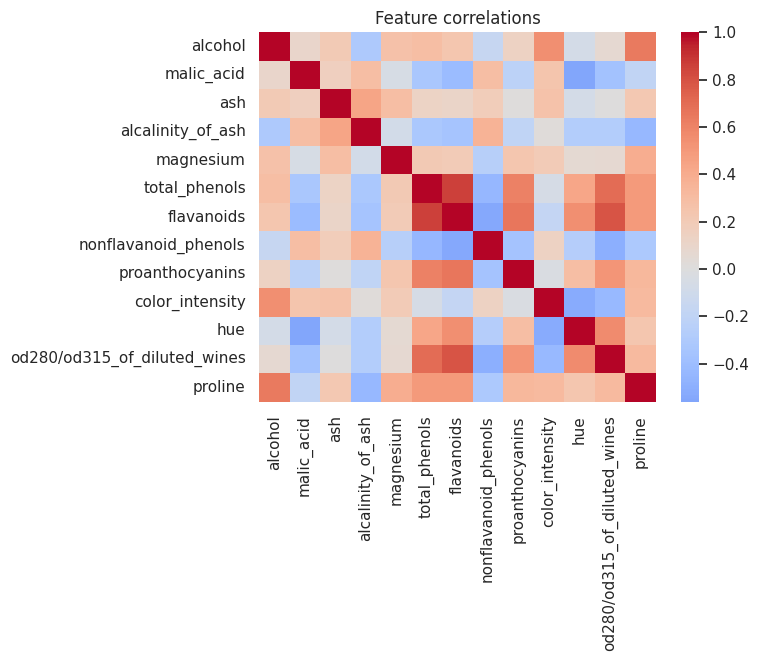

In [3]:
from sklearn.preprocessing import StandardScaler
X = df.drop(columns="variety"); y = df["variety"]
Xs = StandardScaler().fit_transform(X)
sns.heatmap(X.corr(),cmap="coolwarm",center=0,annot=False); plt.title("Feature correlations"); plt.show()

## 2. Choosing the number of clusters

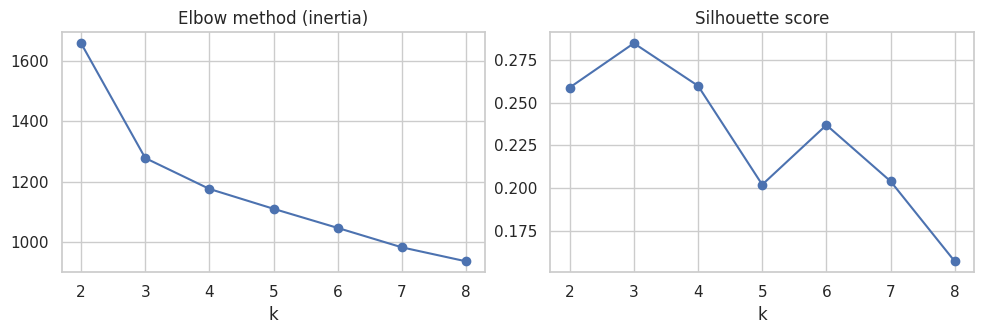

   k  inertia  silhouette
0  2   1658.8       0.259
1  3   1277.9       0.285
2  4   1175.4       0.260
3  5   1109.5       0.202
4  6   1046.0       0.237
5  7    981.6       0.204
6  8    935.2       0.157

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
rows=[]
for k in range(2,9):
    km=KMeans(k,n_init=10,random_state=42).fit(Xs)
    rows.append((k,round(km.inertia_,1),round(silhouette_score(Xs,km.labels_),3)))
res=pd.DataFrame(rows,columns=["k","inertia","silhouette"])
fig,ax=plt.subplots(1,2,figsize=(10,3.5))
ax[0].plot(res.k,res.inertia,"o-"); ax[0].set_title("Elbow method (inertia)"); ax[0].set_xlabel("k")
ax[1].plot(res.k,res.silhouette,"o-"); ax[1].set_title("Silhouette score"); ax[1].set_xlabel("k")
plt.tight_layout(); plt.show()
res

## 3. Final clustering with k = 3

In [5]:
km = KMeans(3,n_init=10,random_state=42).fit(Xs)
df["cluster"] = km.labels_
print("Silhouette:", round(silhouette_score(Xs,km.labels_),3))
df["cluster"].value_counts().sort_index()

Silhouette: 0.285


cluster
0    65
1    51
2    62
Name: count, dtype: int64

Variance explained by the 2 components: 55.4 %


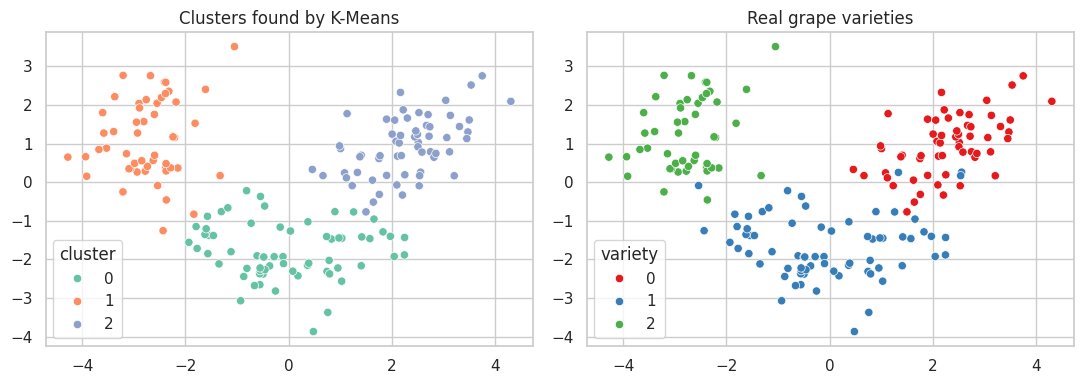

In [6]:
from sklearn.decomposition import PCA
pca = PCA(2).fit(Xs); pts = pca.transform(Xs)
print("Variance explained by the 2 components:", (pca.explained_variance_ratio_.sum()*100).round(1), "%")
fig,ax=plt.subplots(1,2,figsize=(11,4))
sns.scatterplot(x=pts[:,0],y=pts[:,1],hue=df["cluster"],palette="Set2",ax=ax[0]); ax[0].set_title("Clusters found by K-Means")
sns.scatterplot(x=pts[:,0],y=pts[:,1],hue=df["variety"],palette="Set1",ax=ax[1]); ax[1].set_title("Real grape varieties")
plt.tight_layout(); plt.show()

In [7]:
from sklearn.metrics import adjusted_rand_score
print("Adjusted Rand Index vs real varieties:", round(adjusted_rand_score(y,km.labels_),3))
pd.crosstab(df["cluster"],df["variety"],rownames=["cluster"],colnames=["real variety"])

Adjusted Rand Index vs real varieties: 0.897


real variety   0   1   2
cluster                 
0              0  65   0
1              0   3  48
2             59   3   0

## 4. What defines each cluster?

Cluster 0 | highest: ['hue', 'od280/od315_of_diluted_wines', 'alcalinity_of_ash'] | lowest: ['alcohol', 'color_intensity', 'proline']
Cluster 1 | highest: ['color_intensity', 'malic_acid', 'nonflavanoid_phenols'] | lowest: ['od280/od315_of_diluted_wines', 'flavanoids', 'hue']
Cluster 2 | highest: ['proline', 'flavanoids', 'total_phenols'] | lowest: ['alcalinity_of_ash', 'nonflavanoid_phenols', 'malic_acid']


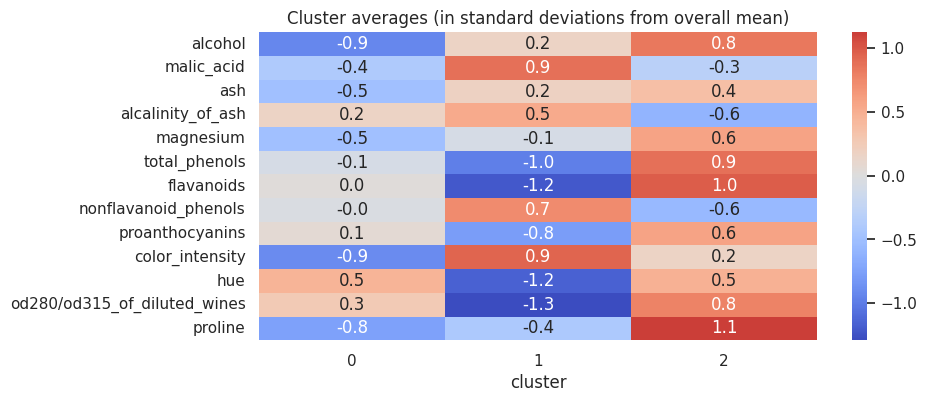

In [8]:
profile = df.groupby("cluster").mean().drop(columns="variety")
z = (profile-X.mean())/X.std()
plt.figure(figsize=(9,4)); sns.heatmap(z.T,annot=True,fmt=".1f",cmap="coolwarm",center=0); plt.title("Cluster averages (in standard deviations from overall mean)"); plt.show()
for c in z.index:
    s=z.loc[c].sort_values()
    print("Cluster",c,"| highest:",list(s.index[-3:][::-1]),"| lowest:",list(s.index[:3]))

## 5. Conclusions
- **Number of clusters:** k = 3 had the best silhouette score (0.285, versus 0.259 for k = 2 and 0.260 for k = 4), and the elbow plot bends around 3, so three groups was a sensible choice.
- **The clusters match reality:** the algorithm never saw the grape variety, yet its three groups matched the real varieties for **172 of 178 wines (96.6%)**. The Adjusted Rand Index is 0.897 (1.0 would be a perfect match). The 6 mismatches were all wines from variety 1 that were placed in the neighbouring clusters.
- **What defines each group:** one group has high proline, flavanoids and total phenols; another has high colour intensity and malic acid but low flavanoids and hue; the third has high hue and low alcohol, colour intensity and proline.
- **Limits:** the silhouette score of 0.285 shows the groups overlap somewhat, the 2D plot only shows 55% of the variation, and 178 wines is a small sample. K-Means also assumes roughly round clusters.
- **Business use:** the same approach can segment customers, products or stores when no labels exist, and then describe what makes each segment different.
